In [46]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [47]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
df.isna().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64

<Axes: >

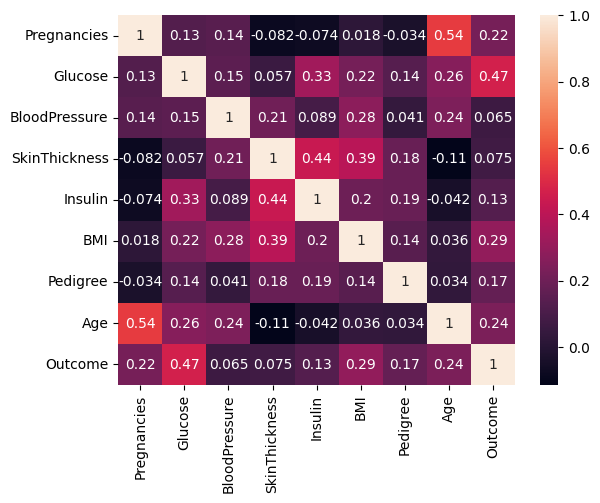

In [49]:
sns.heatmap(df.corr(numeric_only=True) , annot=True)

In [50]:
x = df.drop(["Outcome" , "Insulin" , "SkinThickness"] , axis=1)
y = df["Outcome"]

In [51]:
x["BMI"] = pd.cut(
    x["BMI"] ,
    bins=[ 0 , 18.5 , 24.9 , 29.9 , float("inf") ],
    labels=[ "underwaight" , 'normal' , 'overweight' , 'obese' ],
)

In [52]:
x = pd.get_dummies(x , columns=["BMI"] , drop_first=True)
x = x.astype(int)

In [53]:
x.head()

,Pregnancies,Glucose,BloodPressure,Pedigree,Age,BMI_normal,BMI_overweight,BMI_obese
0,6,148,72,0,50,0,0,1
1,1,85,66,0,31,0,1,0
2,8,183,64,0,32,1,0,0
3,1,89,66,0,21,0,1,0
4,0,137,40,2,33,0,0,1


In [54]:
x["Pedigree"].value_counts()

Pedigree
0    717
1     47
2      4
Name: count, dtype: int64

In [55]:
x.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'Pedigree', 'Age',
       'BMI_normal', 'BMI_overweight', 'BMI_obese'],
      dtype='object')

In [56]:
cols = ["Pregnancies" , "Glucose" , "BloodPressure"  , "Pedigree" , "Age"]
scaler = StandardScaler()
x[cols] = scaler.fit_transform(x[cols])

In [57]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


model = KNeighborsClassifier(n_neighbors=6 , metric='manhattan' , weights='distance')
model.fit(X_train , y_train)
pre = model.predict(X_test)
acc = accuracy_score(y_test , pre)
print("acc =",acc)

acc = 0.7662337662337663


In [58]:
arr = confusion_matrix(y_test , pre)
arr

array([[80, 19],
       [17, 38]])

In [59]:
TP = arr[0][0]
FN = arr[0][1]
FP = arr[1][0]
TN = arr[1][1]

acc = (TP + TN) / (TP + FN + FP + TN)
print(acc)

print("err rate :", 1 - acc)

0.7662337662337663
err rate : 0.23376623376623373


In [60]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)

f1_score = (2 * precision * recall) / (precision + recall)

print("precision" , precision)
print("recall" , recall)
print("specificity" ,specificity)
print("f1_score" , f1_score)

precision 0.8247422680412371
recall 0.8080808080808081
specificity 0.6909090909090909
f1_score 0.8163265306122448


In [61]:
print(classification_report(y_test , pre))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



<Axes: >

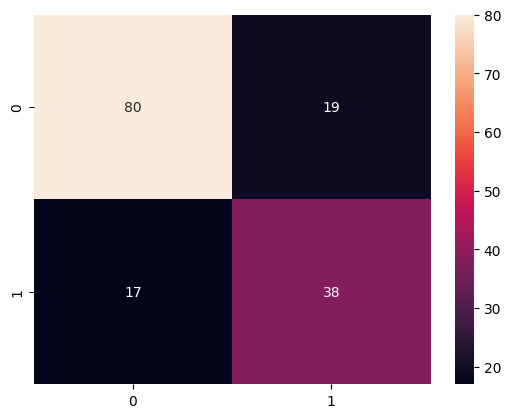

In [ ]:
sns.heatmap(arr , annot=True)

In [ ]:
print(model.classes_)

array([0, 1])